# EV Risk Scoring Model

## Section 1: Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("ggplot") 
np.random.seed(42)

risk_matrix=pd.read_excel("Week3_EV_RiskFactorMatrix_Group_B.xlsx", skiprows=3)
risk_matrix=risk_matrix.dropna(subset=["Risk Factor"])
risk_matrix.head()


,#,Risk Factor,Category,Description / Driver,"Probability\n(1=Low, 5=High)","Severity\n(1=Low, 5=High)",Risk Score\n(P × S),Risk Level,Proposed\nLoading %,Key Data Source,Underwriting Action
1,1,Thermal Runaway — NMC/NCA Chemistry,Battery,NMC/NCA cells release ~300 kJ/Ah on failure vs...,4.0,5.0,20.0,CRITICAL,30–45%,NFPA 855; NHTSA SGO 2021-01; Week 2 Memo S2,Apply NMC/NCA surcharge; require fire suppress...
2,2,Thermal Runaway — LFP Chemistry,Battery,LFP thermal onset at 270°C vs 210°C (NMC); sig...,2.0,4.0,8.0,MEDIUM,10–18%,NFPA 855; BYD Atto 3 spec sheet; Week 2 Memo S1,Base loading; LFP discount vs NMC baseline
3,3,Battery Degradation & Capacity Loss,Battery,LFP retains ~80% capacity at 150k km; NMC degr...,3.0,3.0,9.0,MEDIUM,8–15%,MIT Battery Lab 2023; Tesla Battery Report 2024,Require annual battery health cert after Year ...
4,4,Battery Management System (BMS) Failure,Battery,"BMS failure can allow overcharge, cell imbalan...",2.0,5.0,10.0,HIGH,15–25%,NHTSA complaints EV database; OEM recall notices,Exclusion clause for non-OEM BMS modifications...
5,5,Battery Flood / Water Ingress,Battery,Malaysia's monsoon season creates elevated flo...,4.0,4.0,16.0,HIGH,20–30%,PICC China flood data 2020; Malaysia flood sta...,Flood zone surcharge; require IP67/IP68 batter...


In [3]:
fleet_mix = {
    "BYD_Atto3_LFP": 0.32,
    "Tesla_M3_NMC": 0.18, # 18% Tesla Model 3 LR (NMC)
    "Tesla_M3_NCA": 0.06, # 6% Tesla Model 3 Performance (NCA)
    "Hyundai_Ioniq5": 0.12, # 12% Hyundai Ioniq 5 (NMC)
    "BMW_iX": 0.05, # 5% BMW iX (NMC)
    "Other_BEV": 0.27 # 27% other models
}

N=10000
vehicles=np.random.choice(list(fleet_mix.keys()),size=N,p=list(fleet_mix.values()))

chemistry_map = {
    "BYD_Atto3_LFP": "LFP",
    "Tesla_M3_NMC": "NMC", 
    "Tesla_M3_NCA": "NCA", 
    "Hyundai_Ioniq5": "NMC", 
    "BMW_iX": "NMC", 
    "Other_BEV": "NMC" 
}

si_map = {
    "BYD_Atto3_LFP": (130000, 160000),
    "Tesla_M3_NMC": (185000, 215000),
    "Tesla_M3_NCA": (225000, 250000),
    "Hyundai_Ioniq5":(175000, 210000),
    "BMW_iX": (440000, 550000),
    "Other_BEV": (90000, 160000)    
}

adas_map = {
    'BYD_Atto3_LFP': 'BYD_DiPilot',
    'Tesla_M3_NMC': 'Tesla_Autopilot',
    'Tesla_M3_NCA': 'Tesla_Autopilot',
    'Hyundai_Ioniq5': 'Level1',
    'BMW_iX': 'Level1',
    'Other_BEV': 'None'
}

## Section 2: Exploratory Data Analysis

In [4]:
risk_matrix["Category"].value_counts()

Category
Battery           8
ADAS              7
Repair Cost       5
Environmental     5
Residual Value    4
Infrastructure    4
Name: count, dtype: int64

In [5]:
risk_matrix["Risk Score\n(P × S)"].describe()

count    33.000000
mean     11.484848
std       4.458988
min       4.000000
25%       9.000000
50%      12.000000
75%      15.000000
max      20.000000
Name: Risk Score\n(P × S), dtype: float64

<Axes: >

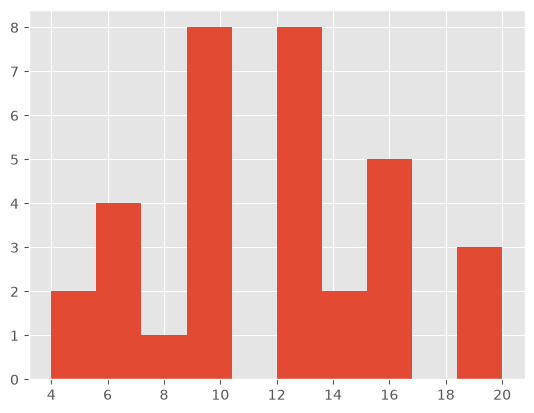

In [6]:
risk_matrix["Risk Score\n(P × S)"].hist()

## Section 3: Risk Factor Definition and Weighing

In [7]:
risk_lookup=dict(zip(risk_matrix["Risk Factor"],risk_matrix["Risk Score\n(P × S)"]))

In [8]:
df=pd.DataFrame({
    "vehicle_type":vehicles,
    "battery_chemistry":[chemistry_map[v] for v in vehicles],
    "adas_level":[adas_map[v] for v in vehicles],
    "driver_age": np.random.normal(38,10,N).clip(18,75).astype(int),
    "ev_experience_years": np.random.choice([0,1,2,3], N, p=[0.3,0.35,0.25,0.1]),
    "garaging": np.random.choice(["basement","covered","open"], N, p=[0.25,0.35,0.40]),
    "state": np.random.choice(["Selangor","KL","Johor","Penang","Other"], N, p=[0.30,0.15,0.15,0.10,0.30]),
    "annual_km": np.random.normal(18000,6000, N).clip(5000,60000),
    "sum_insured": [np.random.randint(*si_map[v]) for v in vehicles]
})
df

,vehicle_type,battery_chemistry,adas_level,driver_age,ev_experience_years,garaging,state,annual_km,sum_insured
0,Tesla_M3_NMC,NMC,Tesla_Autopilot,23,0,covered,Penang,21876.018565,214829
1,Other_BEV,NMC,None,26,0,open,Johor,26017.402202,135911
2,Other_BEV,NMC,None,41,0,open,KL,25533.216072,99428
3,Hyundai_Ioniq5,NMC,Level1,26,0,open,Other,12598.874254,202256
4,BYD_Atto3_LFP,LFP,BYD_DiPilot,49,1,covered,Penang,13527.501305,156849
...,...,...,...,...,...,...,...,...,...
9995,Other_BEV,NMC,None,37,1,open,KL,12893.104994,145943
9996,Other_BEV,NMC,None,45,1,open,Other,5157.596651,110585
9997,Other_BEV,NMC,None,47,3,basement,Selangor,29854.581943,120312
9998,Tesla_M3_NMC,NMC,Tesla_Autopilot,31,1,open,Other,7788.861218,213820


In [9]:
battery_risk = {
    "LFP": 8,
    "NMC": 20,
    "NCA": 20
}

adas_risk = {
    "None": 0,
    "Level1": 4,
    "BYD_DiPilot": 9,
    "Tesla_Autopilot": 16
}

state_risk = {
    "KL": 5,
    "Penang": 8,
    "Selangor": 10,
    "Other": 10,
    "Johor": 16
}

def km_risk(km):
    if km < 10000:
        return 4
    elif km < 20000:
        return 8
    elif km < 30000:
        return 12
    else:
        return 16

## Section 4: Risk Score Calculator

In [10]:
def calculate_ev_risk_score(row):

    score = 0

    score += battery_risk[row["battery_chemistry"]]
    score += state_risk[row["state"]]
    score += km_risk(row["annual_km"])
    score += adas_risk[row["adas_level"]]

    if row["driver_age"] < 25:
        score += 10
    elif row["driver_age"] > 55:
        score += 4
    else:
        score += 6

    if row["ev_experience_years"] == 0:
        score += 10
    elif row["ev_experience_years"] == 1:
        score += 8
    elif row["ev_experience_years"] == 2:
        score += 6
    else:
        score += 4

    return ((score-25)/63)*100

df["risk_score"]=df.apply(calculate_ev_risk_score, axis=1)
def risk_band(score):
    if score<43:
        return "low"
    elif score<67:
        return "medium"
    else:
        return "high"
    
df["risk_band"]=df["risk_score"].apply(risk_band)

## Section 5: Sensitivity Analysis

## Section 6: Synthetic Scenario Testing

In [11]:
base_freq=0.095

chem_freq = {

    'LFP': 0.85,

    'NMC': 1.00,

    'NCA': 1.00

}

garage_freq = {

    'basement': 1.10,

    'covered': 1.00,

    'open': 0.90

}

age_freq = df['driver_age'].apply(

    lambda a: 1.15 if a < 25

    else (0.95 if a > 55 else 1.00)

)

exp_freq = df['ev_experience_years'].map({

    0: 1.15,

    1: 1.08,

    2: 1.00,

    3: 0.95

})

km_freq = df['annual_km'].apply(

    lambda km: 0.90 if km < 10000

    else (1.00 if km < 20000

    else (1.10 if km < 30000

    else 1.20))

)

state_freq = {

    'KL': 0.95,

    'Penang': 1.00,

    'Selangor': 1.05,

    'Other': 1.05,

    'Johor': 1.10

}

df["claim_probability"]=((base_freq)*df["battery_chemistry"].map(chem_freq)*df["garaging"].map(garage_freq)* df['state'].map(state_freq)*age_freq.values* exp_freq.values* km_freq.values).clip(0.01, 0.40)

df["had_claim"]=np.random.binomial(1,df["claim_probability"])

df



,vehicle_type,battery_chemistry,adas_level,driver_age,ev_experience_years,garaging,state,annual_km,sum_insured,risk_score,risk_band,claim_probability,had_claim
0,Tesla_M3_NMC,NMC,Tesla_Autopilot,23,0,covered,Penang,21876.018565,214829,80.952381,high,0.138201,0
1,Other_BEV,NMC,None,26,0,open,Johor,26017.402202,135911,61.904762,medium,0.118973,0
2,Other_BEV,NMC,None,41,0,open,KL,25533.216072,99428,44.444444,medium,0.102750,0
3,Hyundai_Ioniq5,NMC,Level1,26,0,open,Other,12598.874254,202256,52.380952,medium,0.103241,0
4,BYD_Atto3_LFP,LFP,BYD_DiPilot,49,1,covered,Penang,13527.501305,156849,34.920635,low,0.087210,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Other_BEV,NMC,None,37,1,open,KL,12893.104994,145943,34.920635,low,0.087723,0
9996,Other_BEV,NMC,None,45,1,open,Other,5157.596651,110585,36.507937,low,0.087261,0
9997,Other_BEV,NMC,None,47,3,basement,Selangor,29854.581943,120312,42.857143,low,0.114663,0
9998,Tesla_M3_NMC,NMC,Tesla_Autopilot,31,1,open,Other,7788.861218,213820,61.904762,medium,0.087261,0


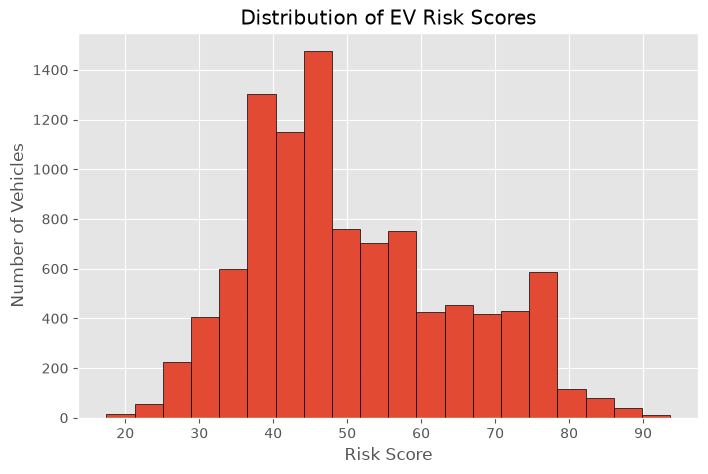

In [12]:
plt.figure(figsize=(8,5))



plt.hist(df["risk_score"], bins=20, edgecolor="black")



plt.title("Distribution of EV Risk Scores")

plt.xlabel("Risk Score")

plt.ylabel("Number of Vehicles")



plt.show()

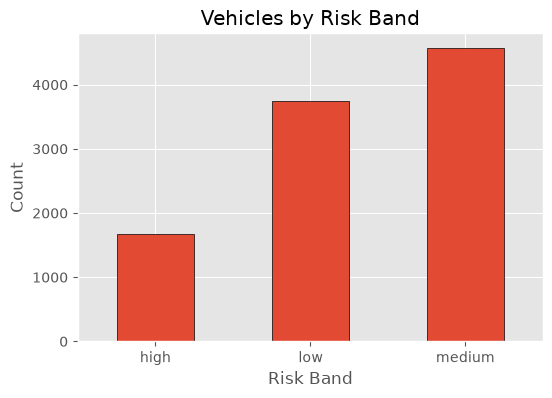

In [13]:
plt.figure(figsize=(6,4))

df["risk_band"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Vehicles by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

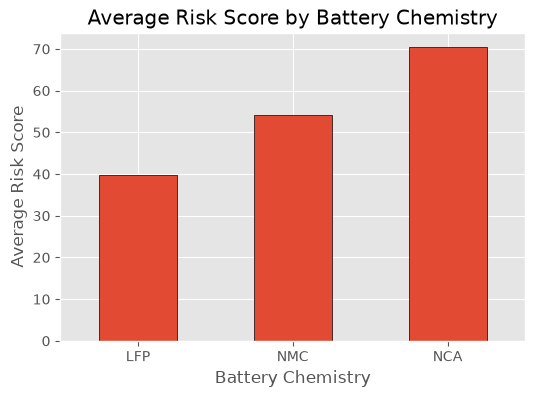

In [14]:
plt.figure(figsize=(6,4))

df.groupby("battery_chemistry")["risk_score"] \
  .mean() \
  .sort_values() \
  .plot(kind="bar", edgecolor="black")

plt.title("Average Risk Score by Battery Chemistry")
plt.xlabel("Battery Chemistry")
plt.ylabel("Average Risk Score")

plt.xticks(rotation=0)

plt.show()

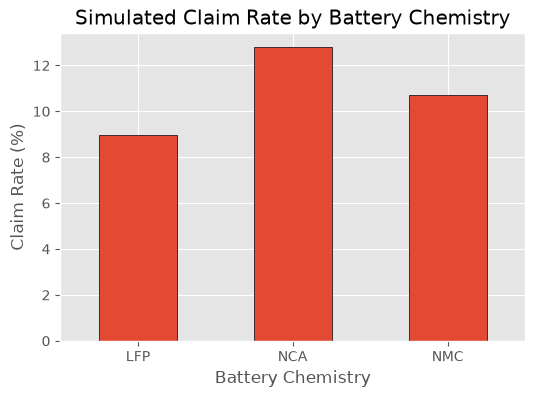

In [15]:
claim_rate = (
    df.groupby("battery_chemistry")["had_claim"]
      .mean()*100
)

plt.figure(figsize=(6,4))

claim_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.ylabel("Claim Rate (%)")
plt.xlabel("Battery Chemistry")
plt.title("Simulated Claim Rate by Battery Chemistry")

plt.xticks(rotation=0)

plt.show()

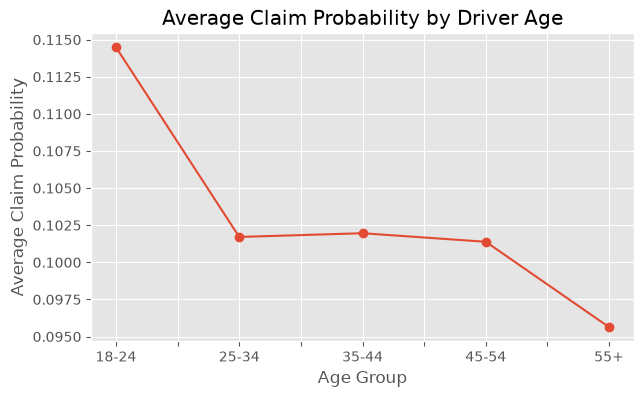

In [16]:
df["age_group"] = pd.cut(
    df["driver_age"],
    bins=[18,25,35,45,55,75],
    labels=["18-24","25-34","35-44","45-54","55+"]
)

plt.figure(figsize=(7,4))

df.groupby("age_group")["claim_probability"] \
  .mean() \
  .plot(marker="o")

plt.title("Average Claim Probability by Driver Age")
plt.xlabel("Age Group")
plt.ylabel("Average Claim Probability")

plt.grid(True)

plt.show()

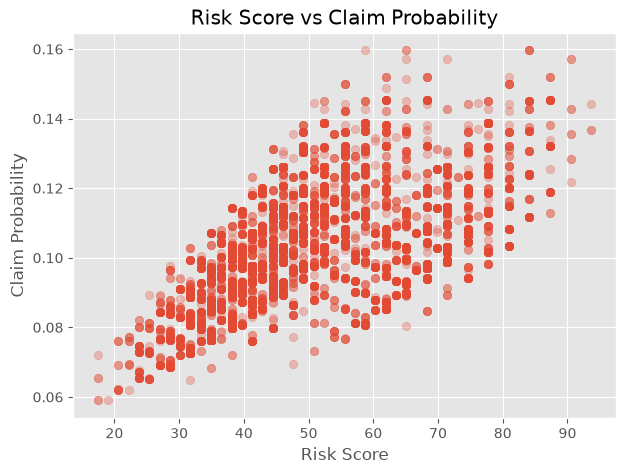

In [17]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["risk_score"],
    df["claim_probability"],
    alpha=0.3
)

plt.title("Risk Score vs Claim Probability")
plt.xlabel("Risk Score")
plt.ylabel("Claim Probability")

plt.show()

In [18]:
top10 = (
    df.nlargest(10,"risk_score")
    [["vehicle_type",
      "battery_chemistry",
      "driver_age",
      "annual_km",
      "risk_score"]]
)

top10

,vehicle_type,battery_chemistry,driver_age,annual_km,risk_score
6066,Tesla_M3_NMC,NMC,47,31229.993065,93.650794
7347,Tesla_M3_NMC,NMC,24,22518.354414,93.650794
9468,Tesla_M3_NCA,NCA,24,20414.927036,93.650794
2093,Tesla_M3_NCA,NCA,23,21948.902299,90.476190
2196,Tesla_M3_NMC,NMC,44,30775.052080,90.476190
2499,Tesla_M3_NMC,NMC,19,23950.539113,90.476190
2839,Tesla_M3_NMC,NMC,23,20034.913792,90.476190
7131,Tesla_M3_NMC,NMC,21,21018.468903,90.476190
7479,Tesla_M3_NMC,NMC,26,30811.195139,90.476190
9126,Tesla_M3_NMC,NMC,35,31346.355787,90.476190


In [19]:
print("Average Risk Score :", round(df["risk_score"].mean(),2))
print("Average Claim Probability :", round(df["claim_probability"].mean()*100,2),"%")
print("Overall Simulated Claim Rate :", round(df["had_claim"].mean()*100,2),"%")

print("\nRisk Band Distribution")
print(df["risk_band"].value_counts(normalize=True)*100)

Average Risk Score : 50.48
Average Claim Probability : 10.3 %
Overall Simulated Claim Rate : 10.27 %

Risk Band Distribution
risk_band
medium    45.71
low       37.48
high      16.81
Name: proportion, dtype: float64


## Section 7: Bayesian Update Demonstration

In [35]:
#PRIOR DISTRIBUTION

alpha_prior=9.5
beta_prior=90.5

prior_mean= alpha_prior/(alpha_prior+beta_prior)
print("Prior Mean:", round(prior_mean*100,2), "%")

prior_dist=stats.beta(alpha_prior,beta_prior)
prior_ci=prior_dist.ppf([0.025,0.975])
print(f"Prior 95% CI: [{prior_ci[0]:.2%}, {prior_ci[1]:.2%}]")


#CURRENT MALAYSIAN DATA

n_observed=0
x_observed=0

print(
    f"\nObserved Data: {x_observed} claims out of {n_observed} policies"
)

#POSTERIOR UPDATE

alpha_post = alpha_prior + x_observed
beta_post = beta_prior + (n_observed - x_observed)

posterior_dist = stats.beta(alpha_post, beta_post)

posterior_mean = (
    alpha_post /
    (alpha_post + beta_post)
)

posterior_ci = posterior_dist.ppf([0.025,0.975])

print(
    f"Posterior Mean: {posterior_mean:.2%}"
)

print(
    f"Posterior 95% CI: [{posterior_ci[0]:.2%}, {posterior_ci[1]:.2%}]"
)




Prior Mean: 9.5 %
Prior 95% CI: [4.59%, 15.93%]

Observed Data: 0 claims out of 0 policies
Posterior Mean: 9.50%
Posterior 95% CI: [4.59%, 15.93%]


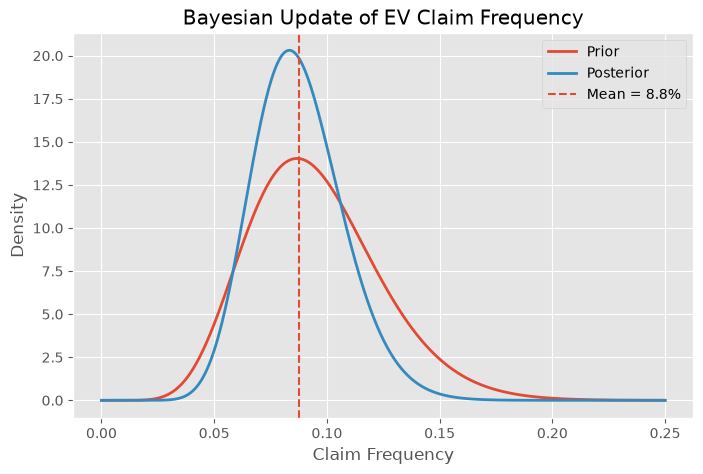

In [23]:
x_vals = np.linspace(0,0.25,500)

plt.figure(figsize=(8,5))

plt.plot(
    x_vals,
    prior_dist.pdf(x_vals),
    label="Prior",
    linewidth=2
)

plt.plot(
    x_vals,
    posterior_dist.pdf(x_vals),
    label="Posterior",
    linewidth=2
)

plt.axvline(
    posterior_mean,
    linestyle="--",
    label=f"Mean = {posterior_mean:.1%}"
)

plt.title("Bayesian Update of EV Claim Frequency")
plt.xlabel("Claim Frequency")
plt.ylabel("Density")
plt.legend()

plt.show()

In [24]:
prior_scenarios = [
    {"name":"Optimistic (7%)","alpha":7.0,"beta":93.0},
    {"name":"Conservative (8%)","alpha":8.0,"beta":92.0},
    {"name":"Our Estimate (9.5%)","alpha":9.5,"beta":90.5},
    {"name":"Cautious (12%)","alpha":12.0,"beta":88.0},
    {"name":"Pessimistic (15%)","alpha":15.0,"beta":85.0},
]

results=[]

for sc in prior_scenarios:

    a=sc["alpha"]
    b=sc["beta"]

    post_a=a+x_observed
    post_b=b+(n_observed-x_observed)

    post_mean=post_a/(post_a+post_b)

    post_dist=stats.beta(post_a,post_b)

    ci=post_dist.ppf([0.025,0.975])

    results.append({
        "Scenario":sc["name"],
        "Posterior Mean":f"{post_mean:.2%}",
        "95% CI":f"[{ci[0]:.2%},{ci[1]:.2%}]"
    })

sens_df=pd.DataFrame(results)

sens_df

,Scenario,Posterior Mean,95% CI
0,Optimistic (7%),7.50%,"[4.28%,11.52%]"
1,Conservative (8%),8.00%,"[4.67%,12.13%]"
2,Our Estimate (9.5%),8.75%,"[5.25%,13.03%]"
3,Cautious (12%),10.00%,"[6.25%,14.51%]"
4,Pessimistic (15%),11.50%,"[7.47%,16.26%]"


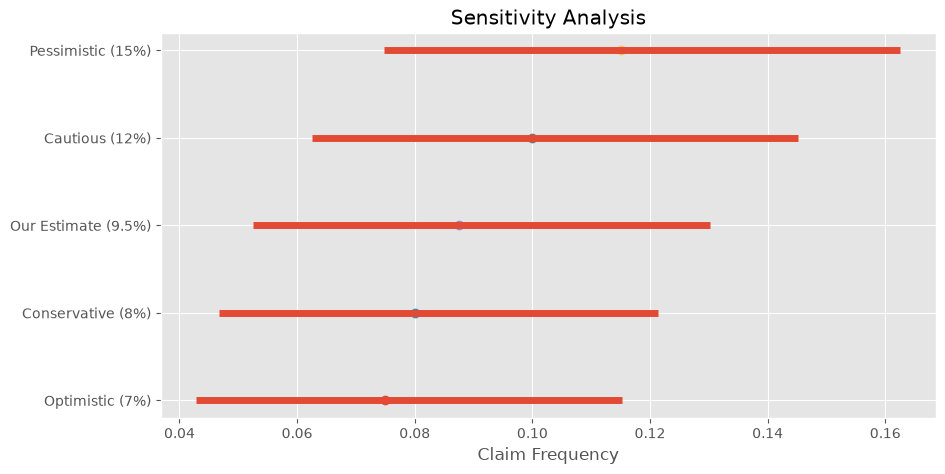

In [25]:
plt.figure(figsize=(10,5))

for i,sc in enumerate(prior_scenarios):

    dist=stats.beta(
        sc["alpha"]+x_observed,
        sc["beta"]+(n_observed-x_observed)
    )

    ci=dist.ppf([0.025,0.975])

    mean=(sc["alpha"]+x_observed)/(
        sc["alpha"]+sc["beta"]+n_observed
    )

    plt.plot(mean,i,'o')
    plt.hlines(
        y=i,
        xmin=ci[0],
        xmax=ci[1],
        linewidth=5
    )

plt.yticks(
    range(len(prior_scenarios)),
    [s["name"] for s in prior_scenarios]
)

plt.xlabel("Claim Frequency")
plt.title("Sensitivity Analysis")
plt.show()

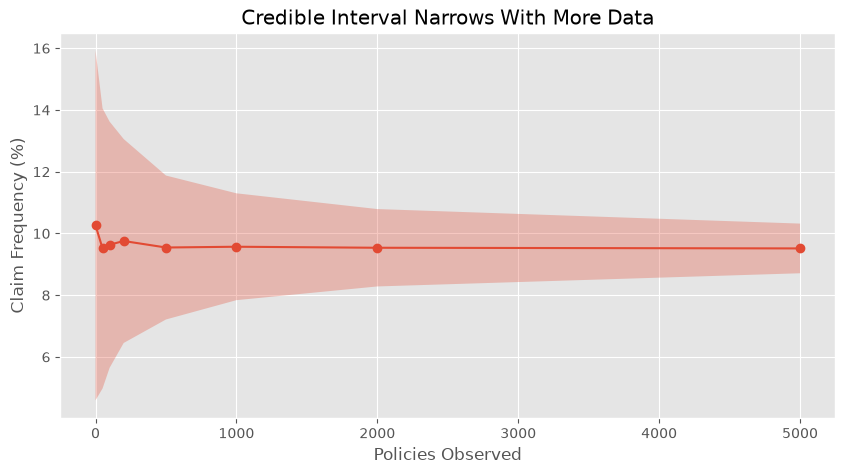

In [26]:
sample_sizes=[0,50,100,200,500,1000,2000,5000]

lower=[]
upper=[]

for n in sample_sizes:

    x=int(0.095*n)

    dist=stats.beta(
        alpha_prior+x,
        beta_prior+n-x
    )

    ci=dist.ppf([0.025,0.975])

    lower.append(ci[0]*100)
    upper.append(ci[1]*100)

plt.figure(figsize=(10,5))

plt.fill_between(
    sample_sizes,
    lower,
    upper,
    alpha=0.3
)

plt.plot(
    sample_sizes,
    [(a+b)/2 for a,b in zip(lower,upper)],
    marker='o'
)

plt.xlabel("Policies Observed")
plt.ylabel("Claim Frequency (%)")

plt.title("Credible Interval Narrows With More Data")

plt.show()

In [ ]:
N_SIMULATIONS=100000

SEVERITY_MEAN=18500
SEVERITY_SIGMA=0.65

theta_samples=posterior_dist.rvs(N_SIMULATIONS)

had_claim=np.random.binomial(
    1,
    theta_samples
)

severity=np.where(
    had_claim,
    np.exp(
        np.random.normal(
            np.log(SEVERITY_MEAN),
            SEVERITY_SIGMA,
            N_SIMULATIONS
        )
    ),
    0
)

claim_losses=severity[severity>0]

expected_loss=severity.mean()

var95=np.percentile(
    claim_losses,
    95
)

print(
    f"Claim Frequency: {had_claim.mean():.2%}"
)

print(
    f"Expected Loss: RM {expected_loss:,.0f}"
)

print(
    f"95% VaR: RM {var95:,.0f}"
)

Claim Frequency: 8.77%
Expected Loss: RM 2,008
95% VaR: RM 16,291


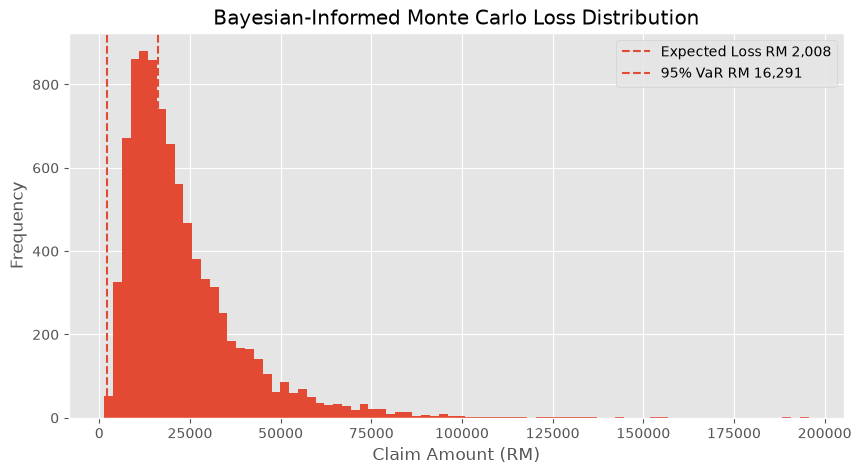

In [34]:
plt.figure(figsize=(10,5))

plt.hist(
    claim_losses,
    bins=80
)

plt.axvline(
    expected_loss,
    linestyle='--',
    label=f'Expected Loss RM {expected_loss:,.0f}'
)

plt.axvline(
    var95,
    linestyle='--',
    label=f'95% VaR RM {var95:,.0f}'
)

plt.title(
    "Bayesian-Informed Monte Carlo Loss Distribution"
)

plt.xlabel("Claim Amount (RM)")
plt.ylabel("Frequency")

plt.legend()

plt.show()

## Section 8: Conclusions